The Ames Housing dataset is a famous dataset to exersice the regression models using machine learning. With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, the challenges is to predict the final price of each home.

# Step 1: Importing the dataset and neccessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


# Step 2: Getting to know the data

In [3]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

As we can see in the information from the dataset we have:

In [4]:
with open('../input/house-prices-advanced-regression-techniques/data_description.txt', 'r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

# Step 3: Dealing with the missing data

In [5]:
df.shape

(1460, 81)

In [6]:
df.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

We can see that the overall quality and then GrLivArea has the most corrolation with the sale price! Let's get a visual view of these two:

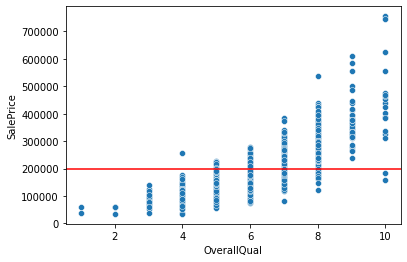

In [7]:
sns.scatterplot(data=df, x='OverallQual', y='SalePrice')
plt.axhline(y=200000,color='r')

As you can see, in overall quality of 10 we have 2 data that are for houses less than 200,000. This does not seem to be reasonable as they are too cheap for a house with the quality of 10. But let's analyze some more to be sure those are outliers.

In [8]:
df[(df['OverallQual']>8) &(df['SalePrice']<200000)][['SalePrice', 'OverallQual']]

,SalePrice,OverallQual
523,184750,10
1298,160000,10


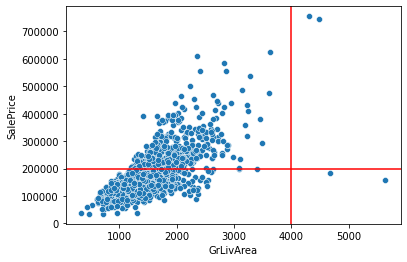

In [9]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.axhline(y=200000, color='r')
plt.axvline(x=4000, color='r')

GrLivArea is above grade (ground) living area square feet. If the house is bigger than 4000 and the sales price is less than 200,000, this is definately something unusual and it can be an outlier.

In [10]:
df[(df['GrLivArea']>4000) & (df['SalePrice']<200000)][['SalePrice', 'GrLivArea']]

,SalePrice,GrLivArea
523,184750,4676
1298,160000,5642


We see that it is the same as before. So let's remove these 2 data from the dataset:

In [11]:
#Remove the outliers:
index_drop=df[(df['GrLivArea']>4000) & (df['SalePrice']<200000)].index
df=df.drop(index_drop, axis=0)

### Nan-values

Now, let's look at the Nan values.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1458 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1458 non-null   int64  
 1   MSSubClass     1458 non-null   int64  
 2   MSZoning       1458 non-null   object 
 3   LotFrontage    1199 non-null   float64
 4   LotArea        1458 non-null   int64  
 5   Street         1458 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1458 non-null   object 
 8   LandContour    1458 non-null   object 
 9   Utilities      1458 non-null   object 
 10  LotConfig      1458 non-null   object 
 11  LandSlope      1458 non-null   object 
 12  Neighborhood   1458 non-null   object 
 13  Condition1     1458 non-null   object 
 14  Condition2     1458 non-null   object 
 15  BldgType       1458 non-null   object 
 16  HouseStyle     1458 non-null   object 
 17  OverallQual    1458 non-null   int64  
 18  OverallC

Some data do not give us useful information. Like Id. So let's drop that:

In [13]:
df= df.drop('Id', axis=1)

How many missing data do we have?

In [14]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

Let's see how many percent of each missing data is null:

In [15]:
def missing_percent(df):
    nan_percent= 100*(df.isnull().sum()/len(df))
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

percentage = missing_percent(df)
percentage

Electrical       0.068587
MasVnrType       0.548697
MasVnrArea       0.548697
BsmtQual         2.537723
BsmtCond         2.537723
BsmtFinType1     2.537723
BsmtExposure     2.606310
BsmtFinType2     2.606310
GarageCond       5.555556
GarageQual       5.555556
GarageFinish     5.555556
GarageType       5.555556
GarageYrBlt      5.555556
LotFrontage     17.764060
FireplaceQu     47.325103
Fence           80.727023
Alley           93.758573
MiscFeature     96.296296
PoolQC          99.588477
dtype: float64

Let's visualize the percentage of missing data on a graph:

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'MasVnrType'),
  Text(2, 0, 'MasVnrArea'),
  Text(3, 0, 'BsmtQual'),
  Text(4, 0, 'BsmtCond'),
  Text(5, 0, 'BsmtFinType1'),
  Text(6, 0, 'BsmtExposure'),
  Text(7, 0, 'BsmtFinType2'),
  Text(8, 0, 'GarageCond'),
  Text(9, 0, 'GarageQual'),
  Text(10, 0, 'GarageFinish'),
  Text(11, 0, 'GarageType'),
  Text(12, 0, 'GarageYrBlt'),
  Text(13, 0, 'LotFrontage'),
  Text(14, 0, 'FireplaceQu'),
  Text(15, 0, 'Fence'),
  Text(16, 0, 'Alley'),
  Text(17, 0, 'MiscFeature'),
  Text(18, 0, 'PoolQC')])

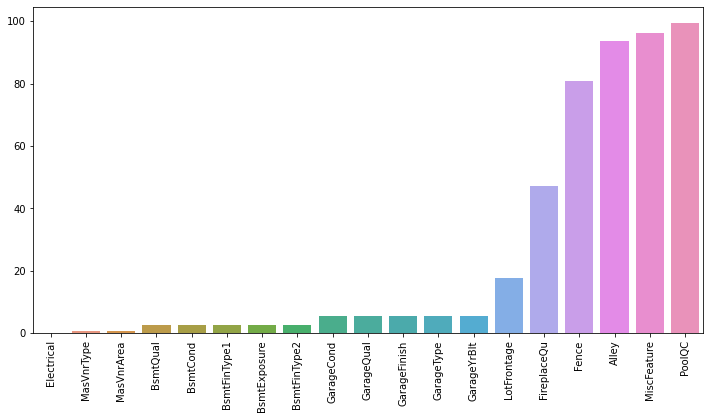

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(x=percentage.index, y=percentage)
plt.xticks(rotation=90)

And now let's look at the ones with less than 1%.

### Less than 1%: Electrical, MasVnrType, MasVnrArea

In [17]:
percentage[percentage<1]

Electrical    0.068587
MasVnrType    0.548697
MasVnrArea    0.548697
dtype: float64

In [18]:
df[df['Electrical'].isnull()][['Electrical']]

,Electrical
1379,NaN


If we look at the data information:
Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed

It is just one row so we drop it.

In [19]:
df[df['MasVnrType'].isnull()][['MasVnrType']]

,MasVnrType
234,NaN
529,NaN
650,NaN
936,NaN
973,NaN
977,NaN
1243,NaN
1278,NaN


If we look at the data information we can see:

MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone

So the ones with null value have no Masonry veneer and this is not a missing data. We should replace it with None.

In [20]:
df[df['MasVnrArea'].isnull()][['MasVnrArea']]

,MasVnrArea
234,NaN
529,NaN
650,NaN
936,NaN
973,NaN
977,NaN
1243,NaN
1278,NaN


If we look at the data information we can see:

MasVnrArea: Masonry veneer area in square feet

We have obviosly a low rate of missing values here, so we also drop them.

In [21]:
df= df.dropna(axis=0, subset=['Electrical', 'MasVnrType', 'MasVnrArea'])

In [22]:
missing_percent(df)

BsmtQual         2.553485
BsmtCond         2.553485
BsmtFinType1     2.553485
BsmtExposure     2.622498
BsmtFinType2     2.622498
GarageType       5.590062
GarageYrBlt      5.590062
GarageFinish     5.590062
GarageQual       5.590062
GarageCond       5.590062
LotFrontage     17.736370
FireplaceQu     47.273982
Fence           80.607315
Alley           93.788820
MiscFeature     96.273292
PoolQC          99.585921
dtype: float64

### Basement data: BsmtQual, BsmtCond, BsmtFinType1, BsmtExposure, BsmtFinType2

Let's look at the information about the basement:

BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
		
BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
		
BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

So the Na values are not missing data, the house simply has no basement. We have to change them to None.

In [23]:
df['BsmtQual']= df['BsmtQual'].fillna('None')
df['BsmtCond']= df['BsmtCond'].fillna('None')
df['BsmtFinType1']= df['BsmtFinType1'].fillna('None')
df['BsmtExposure']= df['BsmtExposure'].fillna('None')
df['BsmtFinType2']= df['BsmtFinType2'].fillna('None')

In [24]:
missing_percent(df)

GarageType       5.590062
GarageYrBlt      5.590062
GarageFinish     5.590062
GarageQual       5.590062
GarageCond       5.590062
LotFrontage     17.736370
FireplaceQu     47.273982
Fence           80.607315
Alley           93.788820
MiscFeature     96.273292
PoolQC          99.585921
dtype: float64

### Garage data: GarageCond, GarageQual, GarageFinish, GarageType, GarageYrBlt

Let's look at the information about the garage:

GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage
		
GarageYrBlt: Year garage was built
		
GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage

So the Na values are not missing data, the house simply has no garage. We have to change them to None.

In [25]:
df['GarageType']= df['GarageType'].fillna('None')
df['GarageYrBlt']= df['GarageYrBlt'].fillna(0)
df['GarageFinish']= df['GarageFinish'].fillna('None')
df['GarageQual']= df['GarageQual'].fillna('None')
df['GarageCond']= df['GarageCond'].fillna('None')

In [26]:
missing_percent(df)

LotFrontage    17.736370
FireplaceQu    47.273982
Fence          80.607315
Alley          93.788820
MiscFeature    96.273292
PoolQC         99.585921
dtype: float64

### More than 80%: Fence, Alley, Miscfeature, PoolQC

For these qualities, the amount of valid data is very low. So we drop these columns:

In [27]:
df= df.drop(['Fence', 'Alley', 'MiscFeature','PoolQC'], axis=1)

In [28]:
missing_percent(df)

LotFrontage    17.736370
FireplaceQu    47.273982
dtype: float64

### Remaining missing data: FireplaceQu

As we can see from the information:
FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace
So the Na values are not missing data, the house simply has no fireplace. We have to change them to None.

In [29]:
df['FireplaceQu']= df['FireplaceQu'].fillna('None')

In [30]:
missing_percent(df)

LotFrontage    17.73637
dtype: float64

### Remaining missing data: LotFrontage 

We have 17.7% of missing data and we cannot just drop it. Lot frontage means the side of a lot abutting on a legally accessible street right-of-way other than an alley or an improved county road. We need to replace the Nan value with a suitable amount.
Let's look if the lot frintage is corrolated with neighbourhood:

<AxesSubplot:xlabel='LotFrontage', ylabel='Neighborhood'>

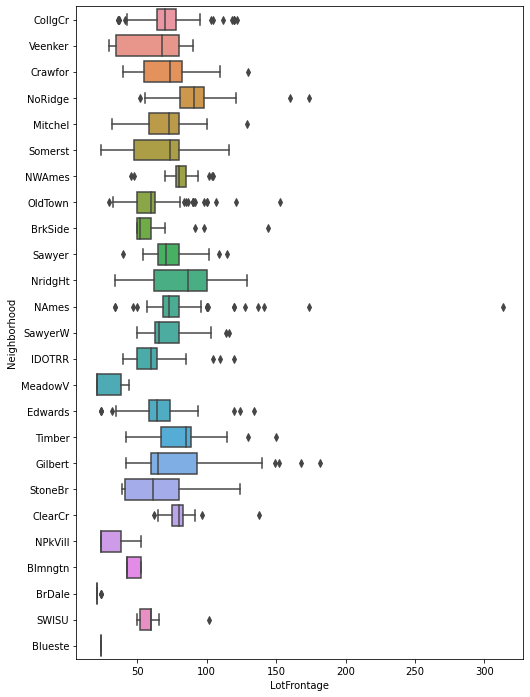

In [31]:
plt.figure(figsize=(8,12))
sns.boxplot(data=df, x='LotFrontage', y='Neighborhood')

In [32]:
df.groupby('Neighborhood')['LotFrontage'].mean()

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.656000
Crawfor    71.804878
Edwards    64.811111
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    91.878788
NridgHt    81.546667
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.591837
Somerst    64.653333
StoneBr    62.700000
Timber     80.379310
Veenker    59.714286
Name: LotFrontage, dtype: float64

We can substitue the missing value with the mean of lot frontage in each neighbourhood:

In [33]:
df['LotFrontage']=df.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

In [34]:
missing_percent(df)

Series([], dtype: float64)

Finally we don't have any missing data!

In [35]:
df.shape

(1449, 76)

In [36]:
df = df.reset_index(drop = True)
df.tail(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1439,90,RL,60.0,9000,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,9,2009,WD,Normal,136000
1440,20,RL,78.0,9262,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,5,2009,New,Partial,287090
1441,180,RM,35.0,3675,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,5,2006,WD,Normal,145000
1442,20,RL,90.0,17217,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2006,WD,Abnorml,84500
1443,20,FV,62.0,7500,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,10,2009,WD,Normal,185000
1444,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1445,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1446,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1447,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125
1448,20,RL,75.0,9937,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2008,WD,Normal,147500


# Step 4: Categorical data

### Numerical Columns to Categorical
We need to be careful when it comes to encoding categorical as numbers. We want to make sure that the numerical relationship makes sense for model. For example, the encoding MSSubClass is essentially just a code per class:

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

So we need to change it to string:

In [37]:
df['MSSubClass']= df['MSSubClass'].apply(str)

### Encoding:

We divide the categorical and numerical features to create dummy variables from the categorical ones:

In [38]:
df_num= df.select_dtypes(exclude='object')
df_obj= df.select_dtypes(include='object')

In [39]:
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1449 non-null   object
 1   MSZoning       1449 non-null   object
 2   Street         1449 non-null   object
 3   LotShape       1449 non-null   object
 4   LandContour    1449 non-null   object
 5   Utilities      1449 non-null   object
 6   LotConfig      1449 non-null   object
 7   LandSlope      1449 non-null   object
 8   Neighborhood   1449 non-null   object
 9   Condition1     1449 non-null   object
 10  Condition2     1449 non-null   object
 11  BldgType       1449 non-null   object
 12  HouseStyle     1449 non-null   object
 13  RoofStyle      1449 non-null   object
 14  RoofMatl       1449 non-null   object
 15  Exterior1st    1449 non-null   object
 16  Exterior2nd    1449 non-null   object
 17  MasVnrType     1449 non-null   object
 18  ExterQual      1449 non-null

Let's do the encoding:

In [40]:
df_obj= pd.get_dummies(df_obj)

In [41]:
df_obj

,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
1445,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1446,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1447,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


# Step 5: Numerical data (feature scaling)

We need to feature scale the numerical data:

In [42]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1449 non-null   float64
 1   LotArea        1449 non-null   int64  
 2   OverallQual    1449 non-null   int64  
 3   OverallCond    1449 non-null   int64  
 4   YearBuilt      1449 non-null   int64  
 5   YearRemodAdd   1449 non-null   int64  
 6   MasVnrArea     1449 non-null   float64
 7   BsmtFinSF1     1449 non-null   int64  
 8   BsmtFinSF2     1449 non-null   int64  
 9   BsmtUnfSF      1449 non-null   int64  
 10  TotalBsmtSF    1449 non-null   int64  
 11  1stFlrSF       1449 non-null   int64  
 12  2ndFlrSF       1449 non-null   int64  
 13  LowQualFinSF   1449 non-null   int64  
 14  GrLivArea      1449 non-null   int64  
 15  BsmtFullBath   1449 non-null   int64  
 16  BsmtHalfBath   1449 non-null   int64  
 17  FullBath       1449 non-null   int64  
 18  HalfBath

In [43]:
df_num

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,...,0,61,0,0,0,0,0,2,2008,208500
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,...,298,0,0,0,0,0,0,5,2007,181500
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,...,0,42,0,0,0,0,0,9,2008,223500
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,...,0,35,272,0,0,0,0,2,2006,140000
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,62.0,7917,6,5,1999,2000,0.0,0,0,953,...,0,40,0,0,0,0,0,8,2007,175000
1445,85.0,13175,6,6,1978,1988,119.0,790,163,589,...,349,0,0,0,0,0,0,2,2010,210000
1446,66.0,9042,7,9,1941,2006,0.0,275,0,877,...,0,60,0,0,0,0,2500,5,2010,266500
1447,68.0,9717,5,6,1950,1996,0.0,49,1029,0,...,366,0,112,0,0,0,0,4,2010,142125


In [44]:
y_train = df_num['SalePrice']
df_num = df_num.drop( ['SalePrice'] , axis=1)
y_train

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1444    175000
1445    210000
1446    266500
1447    142125
1448    147500
Name: SalePrice, Length: 1449, dtype: int64

In [45]:
names_num = df_num.columns

In [46]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(df_num)
df_num = scaler.transform(df_num)
df_num = pd.DataFrame(df_num, columns= names_num)
df_num

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,-0.255014,-0.202755,0.663370,-0.521197,1.059249,0.885251,0.519309,0.621850,-0.289838,-0.942964,...,0.359542,-0.751579,0.230397,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-1.602495,0.138581
1,0.443361,-0.086203,-0.064278,2.172790,0.164330,-0.422865,-0.573089,1.251643,-0.289838,-0.639987,...,-0.054529,1.624718,-0.706853,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-0.489708,-0.613494
2,-0.115339,0.081024,0.663370,-0.521197,0.992959,0.836802,0.329811,0.112458,-0.289838,-0.300834,...,0.641862,-0.751579,-0.061533,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,0.994008,0.138581
3,-0.487805,-0.091270,0.663370,-0.521197,-1.857524,-0.713557,-0.573089,-0.512704,-0.289838,-0.061166,...,0.801844,-0.751579,-0.169087,4.090338,-0.116786,-0.271307,-0.063907,-0.088023,-1.602495,-1.365570
4,0.629595,0.386085,1.391017,-0.521197,0.959814,0.739904,1.377621,0.503764,-0.289838,-0.174217,...,1.714681,0.779458,0.583787,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,2.106795,0.138581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,-0.394689,-0.256774,-0.064278,-0.521197,0.926669,0.739904,-0.573089,-1.012834,-0.289838,0.872635,...,-0.054529,-0.751579,-0.092263,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,0.623079,-0.613494
1445,0.676153,0.276121,-0.064278,0.376799,0.230621,0.158520,0.090152,0.816345,0.717431,0.049624,...,0.133685,2.031400,-0.706853,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-1.602495,1.642732
1446,-0.208455,-0.142756,0.663370,3.070786,-0.995750,1.030597,-0.573089,-0.376095,-0.289838,0.700797,...,-1.033241,-0.751579,0.215032,-0.359643,-0.116786,-0.271307,-0.063907,4.933898,-0.489708,1.642732
1447,-0.115339,-0.074345,-0.791926,0.376799,-0.697443,0.546110,-0.573089,-0.899379,6.068931,-1.282117,...,-1.089705,2.166960,-0.706853,1.472702,-0.116786,-0.271307,-0.063907,-0.088023,-0.860637,1.642732


# Step 6: Merging the categorical and numerical values

In [47]:
x_train= pd.concat([df_num, df_obj], axis=1)
x_train

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.255014,-0.202755,0.663370,-0.521197,1.059249,0.885251,0.519309,0.621850,-0.289838,-0.942964,...,0,0,0,1,0,0,0,0,1,0
1,0.443361,-0.086203,-0.064278,2.172790,0.164330,-0.422865,-0.573089,1.251643,-0.289838,-0.639987,...,0,0,0,1,0,0,0,0,1,0
2,-0.115339,0.081024,0.663370,-0.521197,0.992959,0.836802,0.329811,0.112458,-0.289838,-0.300834,...,0,0,0,1,0,0,0,0,1,0
3,-0.487805,-0.091270,0.663370,-0.521197,-1.857524,-0.713557,-0.573089,-0.512704,-0.289838,-0.061166,...,0,0,0,1,1,0,0,0,0,0
4,0.629595,0.386085,1.391017,-0.521197,0.959814,0.739904,1.377621,0.503764,-0.289838,-0.174217,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,-0.394689,-0.256774,-0.064278,-0.521197,0.926669,0.739904,-0.573089,-1.012834,-0.289838,0.872635,...,0,0,0,1,0,0,0,0,1,0
1445,0.676153,0.276121,-0.064278,0.376799,0.230621,0.158520,0.090152,0.816345,0.717431,0.049624,...,0,0,0,1,0,0,0,0,1,0
1446,-0.208455,-0.142756,0.663370,3.070786,-0.995750,1.030597,-0.573089,-0.376095,-0.289838,0.700797,...,0,0,0,1,0,0,0,0,1,0
1447,-0.115339,-0.074345,-0.791926,0.376799,-0.697443,0.546110,-0.573089,-0.899379,6.068931,-1.282117,...,0,0,0,1,0,0,0,0,1,0


# Step 7: Importing the test dataset and do the changes

## Dealing with the missing data:

We do every change we did on the train dataset, inclusing deleting some columns and changing the MSSubClass to str.

In [48]:
df_test=pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
df_test.shape

(1459, 80)

In [49]:
df_test.drop('Id', axis=1, inplace=True)
df_test.drop(['Fence', 'Alley', 'MiscFeature','PoolQC'], axis=1, inplace=True)
df_test['MSSubClass']= df_test['MSSubClass'].apply(str)

df_test

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,120,0,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,36,0,0,0,0,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,34,0,0,0,0,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,36,0,0,0,0,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,...,82,0,0,144,0,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,6,2006,WD,Normal
1455,160,RM,21.0,1894,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,24,0,0,0,0,0,4,2006,WD,Abnorml
1456,20,RL,160.0,20000,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,0,9,2006,WD,Abnorml
1457,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,32,0,0,0,0,700,7,2006,WD,Normal


In [50]:
df_test.isnull().sum()

MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
Street             0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 75, dtype: int64

In [51]:
missing_percent(df_test)

BsmtUnfSF        0.068540
GarageArea       0.068540
GarageCars       0.068540
KitchenQual      0.068540
TotalBsmtSF      0.068540
BsmtFinSF2       0.068540
BsmtFinSF1       0.068540
SaleType         0.068540
Exterior1st      0.068540
Exterior2nd      0.068540
Utilities        0.137080
Functional       0.137080
BsmtHalfBath     0.137080
BsmtFullBath     0.137080
MSZoning         0.274160
MasVnrArea       1.028101
MasVnrType       1.096642
BsmtFinType2     2.878684
BsmtFinType1     2.878684
BsmtQual         3.015764
BsmtExposure     3.015764
BsmtCond         3.084304
GarageType       5.209047
GarageYrBlt      5.346127
GarageFinish     5.346127
GarageQual       5.346127
GarageCond       5.346127
LotFrontage     15.558602
FireplaceQu     50.034270
dtype: float64

In [52]:
df_test['BsmtQual']= df_test['BsmtQual'].fillna('None')
df_test['BsmtCond']= df_test['BsmtCond'].fillna('None')
df_test['BsmtFinType1']= df_test['BsmtFinType1'].fillna('None')
df_test['BsmtExposure']= df_test['BsmtExposure'].fillna('None')
df_test['BsmtFinType2']= df_test['BsmtFinType2'].fillna('None')
df_test['BsmtFinSF1']= df_test['BsmtFinSF1'].fillna(0)
df_test['BsmtFinSF2']= df_test['BsmtFinSF2'].fillna(0)
df_test['BsmtUnfSF']= df_test['BsmtUnfSF'].fillna(0)
df_test['BsmtFullBath']= df_test['BsmtFullBath'].fillna(0)
df_test['BsmtHalfBath']= df_test['BsmtHalfBath'].fillna(0)
df_test['TotalBsmtSF']= df_test['TotalBsmtSF'].fillna(0)

In [53]:
df_test['GarageType']= df_test['GarageType'].fillna('None')
df_test['GarageYrBlt']= df_test['GarageYrBlt'].fillna(0)
df_test['GarageFinish']= df_test['GarageFinish'].fillna('None')
df_test['GarageQual']= df_test['GarageQual'].fillna('None')
df_test['GarageCond']= df_test['GarageCond'].fillna(0)
df_test['GarageArea']= df_test['GarageArea'].fillna(0)
df_test['GarageCars']= df_test['GarageCars'].fillna(0)

In [54]:
df_test['FireplaceQu']= df_test['FireplaceQu'].fillna('None')
df_test['LotFrontage']=df_test.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

In [55]:
df_test['Electrical'] = df_test['Electrical'].fillna(df['Electrical'].mode()[0])
df_test['MasVnrType'] = df_test['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df_test['MasVnrArea'] = df_test['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0])
df_test['Exterior1st'] = df_test['Exterior1st'].fillna(df['Exterior1st'].mode()[0])
df_test['Exterior2nd'] = df_test['Exterior2nd'].fillna(df['Exterior2nd'].mode()[0])
df_test['KitchenQual'] = df_test['KitchenQual'].fillna(df['KitchenQual'].mode()[0])
df_test['SaleType'] = df_test['SaleType'].fillna(df['SaleType'].mode()[0])
df_test['Utilities'] = df_test['Utilities'].fillna(df['Utilities'].mode()[0])
df_test['MSZoning'] = df_test['MSZoning'].fillna(df['MSZoning'].mode()[0])
df_test['Functional'] = df_test['Functional'].fillna(df['Functional'].mode()[0])

In [56]:
missing_percent(df_test)

Series([], dtype: float64)

### Categorical data (creating dummy variables)

In [57]:
df_num_test= df_test.select_dtypes(exclude='object')
df_obj_test= df_test.select_dtypes(include='object')

In [58]:
df_obj_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1459 non-null   object
 1   MSZoning       1459 non-null   object
 2   Street         1459 non-null   object
 3   LotShape       1459 non-null   object
 4   LandContour    1459 non-null   object
 5   Utilities      1459 non-null   object
 6   LotConfig      1459 non-null   object
 7   LandSlope      1459 non-null   object
 8   Neighborhood   1459 non-null   object
 9   Condition1     1459 non-null   object
 10  Condition2     1459 non-null   object
 11  BldgType       1459 non-null   object
 12  HouseStyle     1459 non-null   object
 13  RoofStyle      1459 non-null   object
 14  RoofMatl       1459 non-null   object
 15  Exterior1st    1459 non-null   object
 16  Exterior2nd    1459 non-null   object
 17  MasVnrType     1459 non-null   object
 18  ExterQual      1459 non-null

In [59]:
df_obj_test= pd.get_dummies(df_obj_test)

As you can see we have 248 columns. We need to make the columns like the columns of train dataset. We remove the columns which have extra amounts that do not exist in the train dataset:

In [60]:
for i in df_obj_test.columns:
    if i not in df_obj.columns:
         df_obj_test = df_obj_test.drop(columns = i, axis=1)

df_obj_test = df_obj_test.reindex(columns = df_obj.columns, fill_value=0)

In [61]:
df_obj_test

,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1455,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1456,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1457,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


### Numerical data (feature scaling)

In [62]:
df_num_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotFrontage    1459 non-null   float64
 1   LotArea        1459 non-null   int64  
 2   OverallQual    1459 non-null   int64  
 3   OverallCond    1459 non-null   int64  
 4   YearBuilt      1459 non-null   int64  
 5   YearRemodAdd   1459 non-null   int64  
 6   MasVnrArea     1459 non-null   float64
 7   BsmtFinSF1     1459 non-null   float64
 8   BsmtFinSF2     1459 non-null   float64
 9   BsmtUnfSF      1459 non-null   float64
 10  TotalBsmtSF    1459 non-null   float64
 11  1stFlrSF       1459 non-null   int64  
 12  2ndFlrSF       1459 non-null   int64  
 13  LowQualFinSF   1459 non-null   int64  
 14  GrLivArea      1459 non-null   int64  
 15  BsmtFullBath   1459 non-null   float64
 16  BsmtHalfBath   1459 non-null   float64
 17  FullBath       1459 non-null   int64  
 18  HalfBath

In [63]:
df_num_test = scaler.transform(df_num_test)
df_num_test = pd.DataFrame(df_num_test, columns= names_num)
df_num_test

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.443361,0.118726,-0.791926,0.376799,-0.332847,-1.149595,-0.573089,0.070781,0.600019,-0.671641,...,1.215915,0.364802,-0.706853,-0.359643,-0.116786,1.874079,-0.063907,-0.088023,-0.118779,1.642732
1,0.489920,0.386795,-0.064278,0.376799,-0.432282,-1.294941,0.028844,1.124295,-0.289838,-0.364143,...,-0.750920,2.382263,-0.153722,-0.359643,-0.116786,-0.271307,-0.063907,25.021581,-0.118779,1.642732
2,0.164011,0.342505,-0.791926,-0.521197,0.860378,0.643007,-0.573089,0.818660,-0.289838,-0.972357,...,0.048989,0.938941,-0.184451,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-1.231566,1.642732
3,0.350245,-0.047893,-0.064278,0.376799,0.893524,0.643007,-0.461620,0.381047,-0.289838,-0.549546,...,-0.007475,2.119116,-0.153722,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-0.118779,1.642732
4,-1.279297,-0.551903,1.391017,-0.521197,0.694653,0.352315,-0.573089,-0.403880,-0.289838,1.017340,...,0.161917,-0.751579,0.553057,-0.359643,-0.116786,2.303157,-0.063907,-0.088023,-1.973424,1.642732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,-2.303580,-0.862944,-1.519573,1.274794,-0.034540,-0.713557,-0.573089,-1.012834,-0.289838,-0.047600,...,-2.218988,-0.751579,-0.706853,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-0.118779,-1.365570
1455,-2.303580,-0.867201,-1.519573,-0.521197,-0.034540,-0.713557,-0.573089,-0.429349,-0.289838,-0.617377,...,-0.873259,-0.751579,-0.338099,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,-0.860637,-1.365570
1456,4.168027,0.967831,-0.791926,1.274794,-0.365992,0.546110,-0.573089,1.821236,-0.289838,-1.282117,...,0.491291,3.028169,-0.706853,-0.359643,-0.116786,-0.271307,-0.063907,-0.088023,0.994008,-1.365570
1457,-0.394689,-0.000968,-0.791926,-0.521197,0.694653,0.352315,-0.573089,-0.232539,-0.289838,0.017970,...,-2.218988,-0.113647,-0.215181,-0.359643,-0.116786,-0.271307,-0.063907,1.318115,0.252150,-1.365570


### Merging the categorical and numerical data

In [64]:
x_test= pd.concat([df_num_test, df_obj_test], axis=1)
x_test

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.443361,0.118726,-0.791926,0.376799,-0.332847,-1.149595,-0.573089,0.070781,0.600019,-0.671641,...,0,0,0,1,0,0,0,0,1,0
1,0.489920,0.386795,-0.064278,0.376799,-0.432282,-1.294941,0.028844,1.124295,-0.289838,-0.364143,...,0,0,0,1,0,0,0,0,1,0
2,0.164011,0.342505,-0.791926,-0.521197,0.860378,0.643007,-0.573089,0.818660,-0.289838,-0.972357,...,0,0,0,1,0,0,0,0,1,0
3,0.350245,-0.047893,-0.064278,0.376799,0.893524,0.643007,-0.461620,0.381047,-0.289838,-0.549546,...,0,0,0,1,0,0,0,0,1,0
4,-1.279297,-0.551903,1.391017,-0.521197,0.694653,0.352315,-0.573089,-0.403880,-0.289838,1.017340,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,-2.303580,-0.862944,-1.519573,1.274794,-0.034540,-0.713557,-0.573089,-1.012834,-0.289838,-0.047600,...,0,0,0,1,0,0,0,0,1,0
1455,-2.303580,-0.867201,-1.519573,-0.521197,-0.034540,-0.713557,-0.573089,-0.429349,-0.289838,-0.617377,...,0,0,0,1,1,0,0,0,0,0
1456,4.168027,0.967831,-0.791926,1.274794,-0.365992,0.546110,-0.573089,1.821236,-0.289838,-1.282117,...,0,0,0,1,1,0,0,0,0,0
1457,-0.394689,-0.000968,-0.791926,-0.521197,0.694653,0.352315,-0.573089,-0.232539,-0.289838,0.017970,...,0,0,0,1,0,0,0,0,1,0


# Step 8: Building a model (Linear Regression)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [66]:
y_pred=lr.predict(x_test)
y_pred

array([ 1.06630000e+05,  1.60962000e+05,  1.90192000e+05, ...,
        1.80502000e+05, -5.28268401e+14,  2.19830000e+05])

In [67]:
y_test=pd.read_csv('../input/house-prices-advanced-regression-techniques/sample_submission.csv')
y_test.shape

(1459, 2)

In [68]:
y_test = y_test['SalePrice']
y_test

0       169277.052498
1       187758.393989
2       183583.683570
3       179317.477511
4       150730.079977
            ...      
1454    167081.220949
1455    164788.778231
1456    219222.423400
1457    184924.279659
1458    187741.866657
Name: SalePrice, Length: 1459, dtype: float64

In [69]:
from sklearn import metrics
MAE=metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)

In [70]:
pd.DataFrame(data=[MAE,MSE,RMSE],index=["MAE","MSE","RMSE"],columns=["LinearRegression"])

,LinearRegression
MAE,3.405380e+13
MSE,2.992439e+28
RMSE,1.729867e+14
